In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter

In [ ]:
INPUT_FOLDER = "input_images"
OUTPUT_FOLDER = "augmented_images"

os.makedirs(INPUT_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Input folder:", INPUT_FOLDER)
print("Output folder:", OUTPUT_FOLDER)

Input folder: input_images
Output folder: augmented_images


In [ ]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_files = [
    file for file in os.listdir(INPUT_FOLDER)
    if file.lower().endswith(valid_extensions)
]

print("Number of images:", len(image_files))

for file in image_files:
    print(file)

Number of images: 10
images_01.jpeg
images_08.jpeg
images_02.jpeg
images_04.jpeg
images_05.jpeg
images_03.jpeg
images_07.jpeg
images_09.jpeg
images_06.jpeg
images_10.jpeg


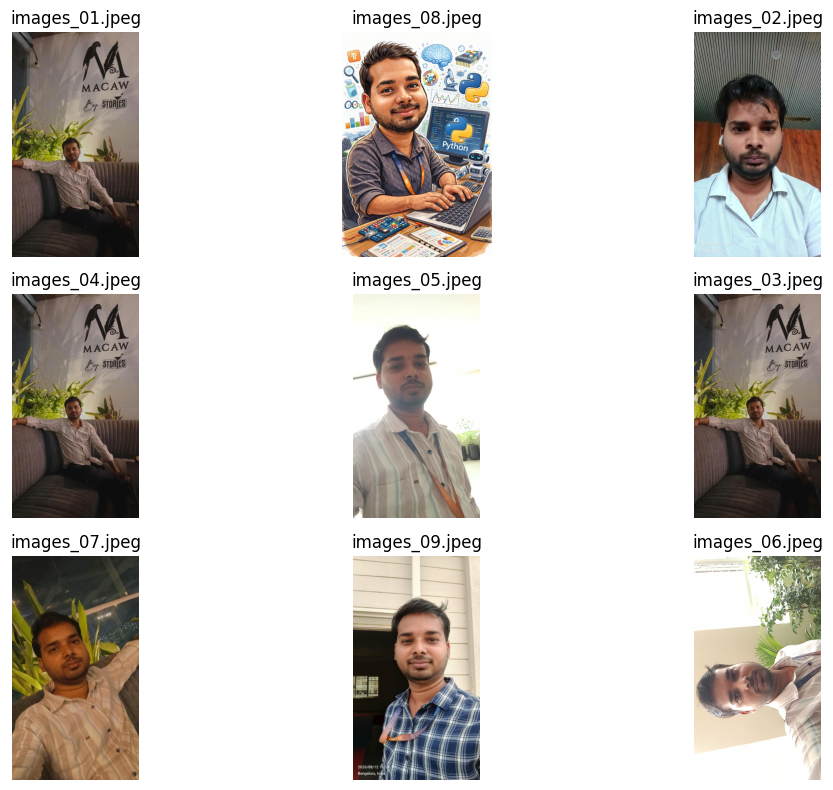

In [ ]:
#  Display Your Original Images
num_images = min(len(image_files), 9)

plt.figure(figsize=(12, 8))

for i in range(num_images):
    image_path = os.path.join(INPUT_FOLDER, image_files[i])
    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(image_files[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create Augmentation Functions

In [ ]:
# 1. Rotation
def rotate_image(image):
    return image.rotate(30)

In [ ]:
# 2. Horizontal Flip
def flip_image(image):
    return image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

In [ ]:
# 3. Brightness
def brightness_image(image):
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(1.5)

In [ ]:
# 4. Contrast
def contrast_image(image):
    enhancer = ImageEnhance.Contrast(image)
    return enhancer.enhance(1.5)

In [ ]:
# 5. Sharpness
def sharpen_image(image):
    enhancer = ImageEnhance.Sharpness(image)
    return enhancer.enhance(2.0)

In [ ]:
# 6. Blur
def blur_image(image):
    return image.filter(ImageFilter.GaussianBlur(radius=1))

In [ ]:
# Zoom/Crop
def zoom_image(image):
    width, height = image.size

    crop_width = int(width * 0.8)
    crop_height = int(height * 0.8)

    left = (width - crop_width) // 2
    top = (height - crop_height) // 2

    right = left + crop_width
    bottom = top + crop_height

    cropped = image.crop((left, top, right, bottom))

    return cropped.resize((width, height))

In [ ]:
def add_noise(image):
    image_array = np.array(image).astype(np.int16)

    noise = np.random.normal(
        loc=0,
        scale=15,
        size=image_array.shape
    )

    noisy_image = image_array + noise

    noisy_image = np.clip(noisy_image, 0, 255)

    return Image.fromarray(noisy_image.astype(np.uint8))

In [ ]:
# Test Augmentations on One Image
sample_file = image_files[0]

sample_path = os.path.join(INPUT_FOLDER, sample_file)

original = Image.open(sample_path).convert("RGB")

augmented_images = [
    ("Original", original),
    ("Rotated", rotate_image(original)),
    ("Flipped", flip_image(original)),
    ("Bright", brightness_image(original)),
    ("Contrast", contrast_image(original)),
    ("Sharp", sharpen_image(original)),
    ("Blur", blur_image(original)),
    ("Zoom", zoom_image(original)),
    ("Noise", add_noise(original))
]

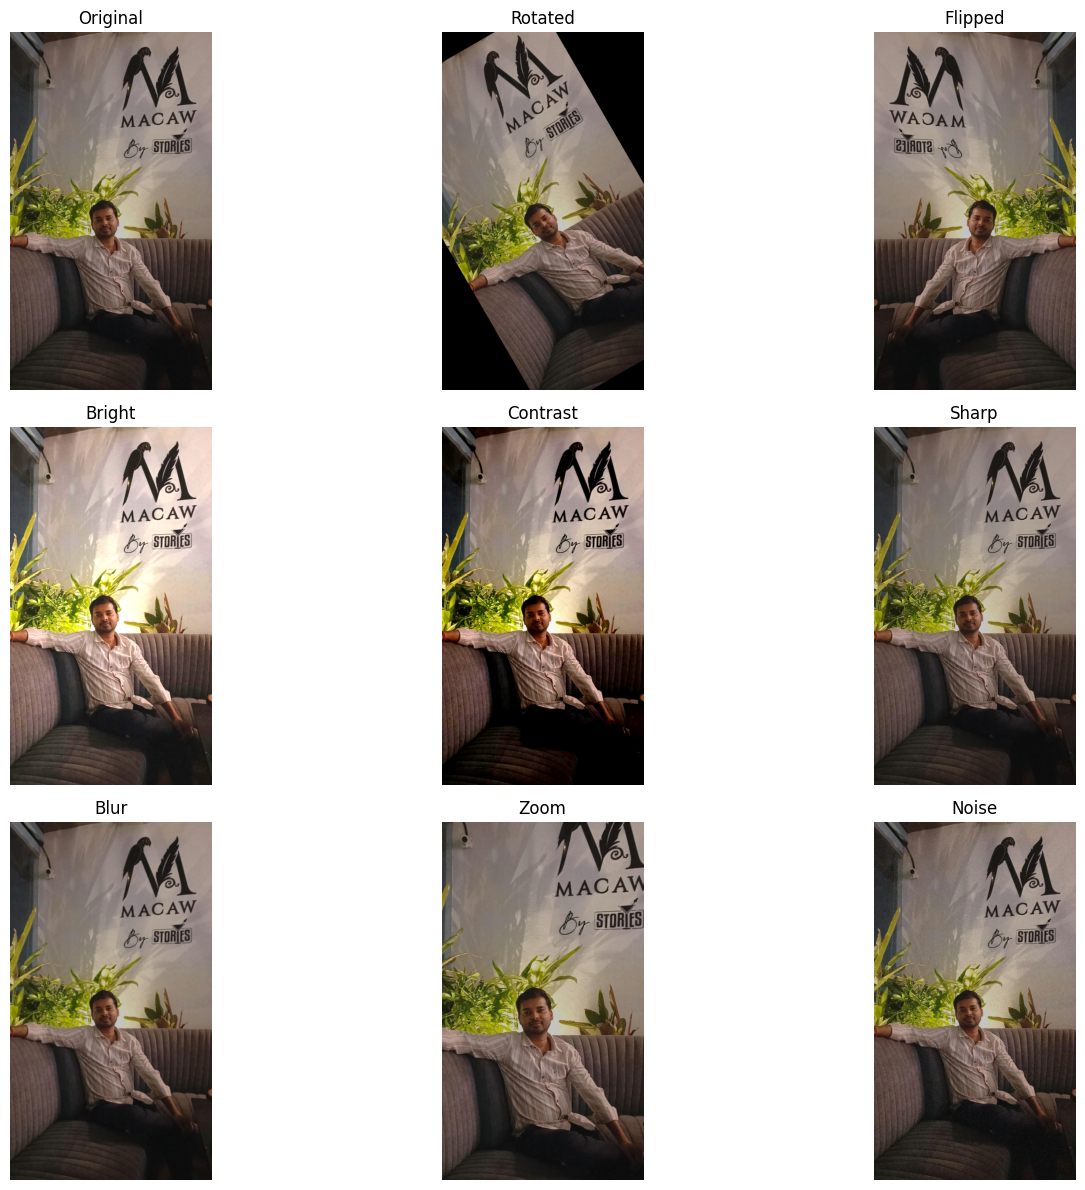

In [ ]:
# Display All Augmentations
plt.figure(figsize=(15, 12))

for i, (title, image) in enumerate(augmented_images):

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(title)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Save Augmented Images
for file in image_files:

    image_path = os.path.join(INPUT_FOLDER, file)

    image = Image.open(image_path).convert("RGB")

    name = os.path.splitext(file)[0]

    transformations = {
        "original": image,
        "rotated": rotate_image(image),
        "flipped": flip_image(image),
        "bright": brightness_image(image),
        "contrast": contrast_image(image),
        "sharp": sharpen_image(image),
        "blur": blur_image(image),
        "zoom": zoom_image(image),
        "noise": add_noise(image)
    }

    for transformation_name, transformed_image in transformations.items():

        output_name = f"{name}_{transformation_name}.jpg"

        output_path = os.path.join(
            OUTPUT_FOLDER,
            output_name
        )

        transformed_image.save(output_path)

print("Augmentation completed!")

Augmentation completed!


In [ ]:
# Check Generated Images
generated_files = [
    file for file in os.listdir(OUTPUT_FOLDER)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Generated images:", len(generated_files))

Generated images: 90


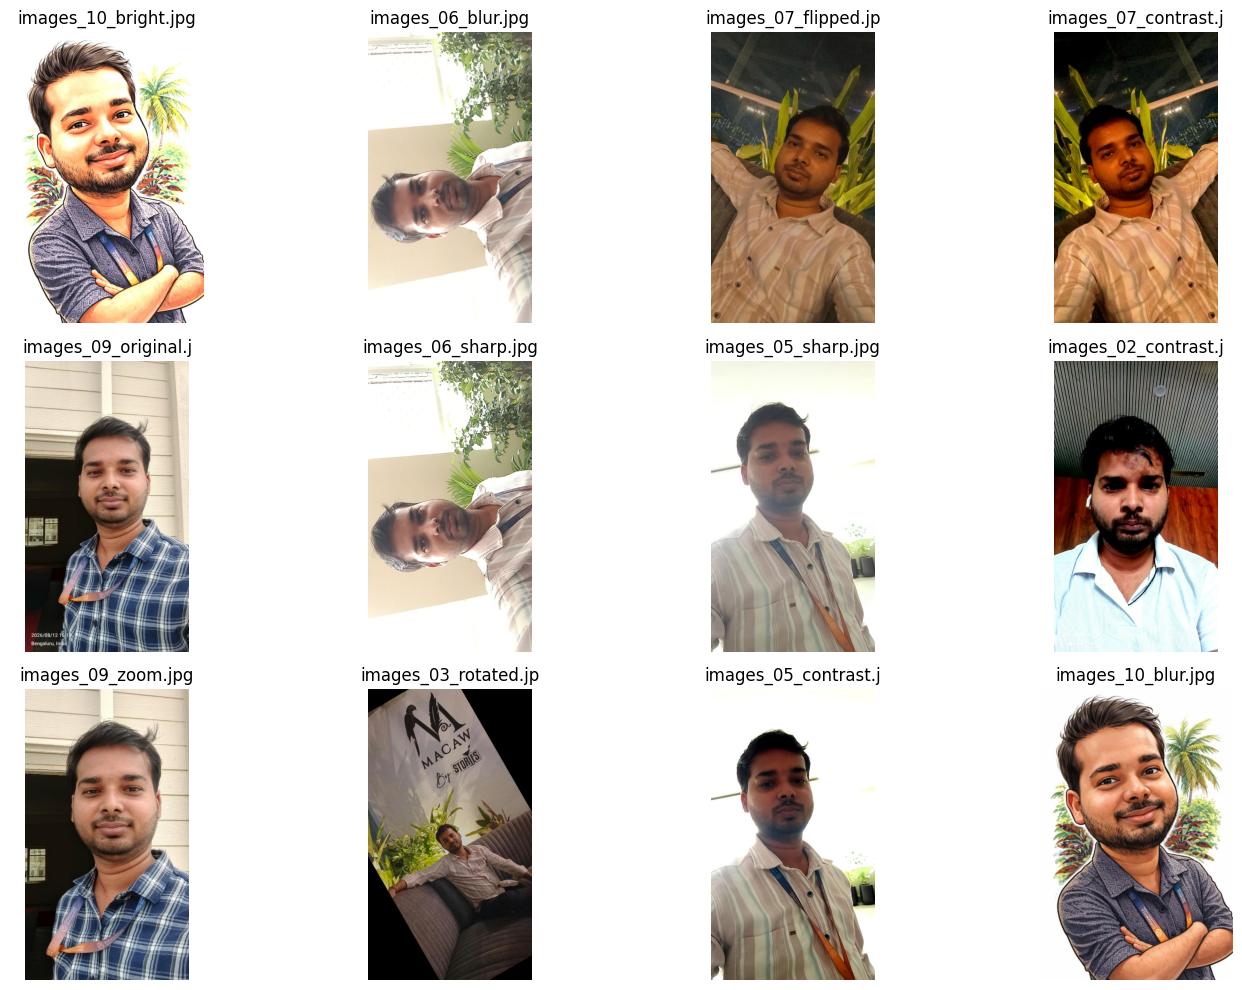

In [ ]:
# Display Generated Images
num_images = min(len(generated_files), 12)

plt.figure(figsize=(15, 10))

for i in range(num_images):

    image_path = os.path.join(
        OUTPUT_FOLDER,
        generated_files[i]
    )

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(generated_files[i][:20])

    plt.axis("off")

plt.tight_layout()
plt.show()

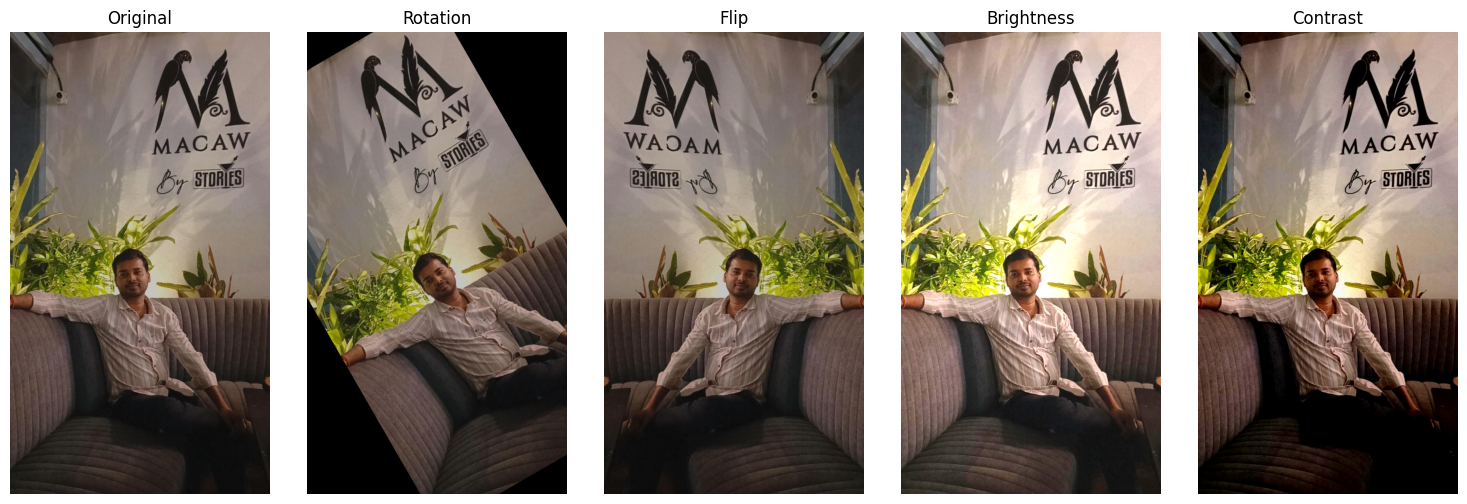

In [ ]:
# Create Original vs Augmented Comparison
sample_file = image_files[0]

original_path = os.path.join(
    INPUT_FOLDER,
    sample_file
)

original = Image.open(original_path).convert("RGB")

rotated = rotate_image(original)
flipped = flip_image(original)
bright = brightness_image(original)
contrast = contrast_image(original)

comparison = [
    ("Original", original),
    ("Rotation", rotated),
    ("Flip", flipped),
    ("Brightness", bright),
    ("Contrast", contrast)
]

plt.figure(figsize=(15, 5))

for i, (title, image) in enumerate(comparison):

    plt.subplot(1, 5, i + 1)

    plt.imshow(image)

    plt.title(title)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Count Before and After
original_count = len(image_files)
augmented_count = len(generated_files)

print("Original Images :", original_count)
print("Generated Images:", augmented_count)
print("Total Increase  :", augmented_count - original_count)

Original Images : 10
Generated Images: 90
Total Increase  : 80
